In [1]:
pip install textstat

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from textstat import textstat

base = "/Users/joannehui/Desktop/fyp/padchest/Reports_public"

english_targets = {
    f"{base}/reports_500_medgemma_lay.csv": ["medgemma_lay_en"],
    f"{base}/reports_500_translated_mistral_lay.csv": ["lay_translation"],
    f"{base}/reports_500_medgemma_nllb_bi.csv": ["medgemma_lay_en"],
    f"{base}/reports_500_medgemma_opusmt_bi.csv": ["medgemma_lay_en"],
    f"{base}/reports_500_translated_mistral_nllb_zh.csv": ["lay_translation"],
    f"{base}/reports_500_translated_zh_mistral_opus.csv": ["lay_translation"],
}
results = []

for fname, cols in english_targets.items():
    df = pd.read_csv(fname)
    for col in cols:
        # drop NaN or empty
        texts = df[col].fillna("").astype(str)
        fk_scores = []
        for t in texts:
            if t.strip():
                fk_scores.append(textstat.flesch_kincaid_grade(t))
            else:
                fk_scores.append(float("nan"))
        df[f"{col}_FK"] = fk_scores

        desc = df[f"{col}_FK"].describe()
        results.append({
            "file": fname,
            "column": col,
            "count": desc["count"],
            "mean_FK": desc["mean"],
            "std_FK": desc["std"],
            "min_FK": desc["min"],
            "p25_FK": desc["25%"],
            "median_FK": desc["50%"],
            "p75_FK": desc["75%"],
            "max_FK": desc["max"],
        })

summary = pd.DataFrame(results)
summary


,file,column,count,mean_FK,std_FK,min_FK,p25_FK,median_FK,p75_FK,max_FK
0,/Users/joannehui/Desktop/fyp/padchest/Reports_...,medgemma_lay_en,417.0,6.390154,2.520873,1.500000,4.485714,6.423590,8.087692,12.278721
1,/Users/joannehui/Desktop/fyp/padchest/Reports_...,lay_translation,417.0,9.417143,1.096525,6.491429,8.698516,9.339616,10.175385,13.304046
2,/Users/joannehui/Desktop/fyp/padchest/Reports_...,medgemma_lay_en,417.0,6.390154,2.520873,1.500000,4.485714,6.423590,8.087692,12.278721
3,/Users/joannehui/Desktop/fyp/padchest/Reports_...,medgemma_lay_en,417.0,6.390154,2.520873,1.500000,4.485714,6.423590,8.087692,12.278721
4,/Users/joannehui/Desktop/fyp/padchest/Reports_...,lay_translation,417.0,9.417143,1.096525,6.491429,8.698516,9.339616,10.175385,13.304046
5,/Users/joannehui/Desktop/fyp/padchest/Reports_...,lay_translation,417.0,9.417143,1.096525,6.491429,8.698516,9.339616,10.175385,13.304046


# make csv with Fk score

In [4]:
for fname, cols in english_targets.items():
    df = pd.read_csv(fname)
    for col in cols:
        texts = df[col].fillna("").astype(str)
        df[f"{col}_FK"] = [
            textstat.flesch_kincaid_grade(t) if t.strip() else float("nan")
            for t in texts
        ]
    df.to_csv(fname.replace(".csv", "_withFK.csv"), index=False)


# Plots

In [5]:
import pandas as pd
from textstat import textstat

base = "/Users/joannehui/Desktop/fyp/padchest/Reports_public"

configs = [
    ("medgemma_lay", f"{base}/reports_500_medgemma_lay.csv", "medgemma_lay_en"),
    ("mistral_lay",  f"{base}/reports_500_translated_mistral_lay.csv", "lay_translation"),
]

all_rows = []

for pipeline, path, col in configs:
    df = pd.read_csv(path)
    texts = df[col].fillna("").astype(str)
    fk = [
        textstat.flesch_kincaid_grade(t) if t.strip() else float("nan")
        for t in texts
    ]
    tmp = pd.DataFrame({
        "pipeline": pipeline,
        "fk_grade": fk,
    })
    all_rows.append(tmp)

fk_long = pd.concat(all_rows, ignore_index=True)
fk_long = fk_long.dropna(subset=["fk_grade"])
fk_long.head()


,pipeline,fk_grade
0,medgemma_lay,6.305714
1,medgemma_lay,4.427097
3,medgemma_lay,4.823333
4,medgemma_lay,9.385488
5,medgemma_lay,9.385488


In [6]:
pip install seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 25.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 23.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


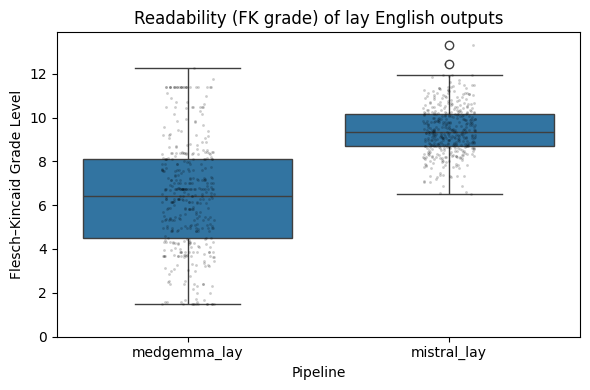

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(data=fk_long, x="pipeline", y="fk_grade")
sns.stripplot(data=fk_long, x="pipeline", y="fk_grade",
              color="black", alpha=0.2, size=2)  # optional jitter points

plt.ylabel("Flesch–Kincaid Grade Level")
plt.xlabel("Pipeline")
plt.title("Readability (FK grade) of lay English outputs")
plt.ylim(0, None)
plt.tight_layout()
plt.show()


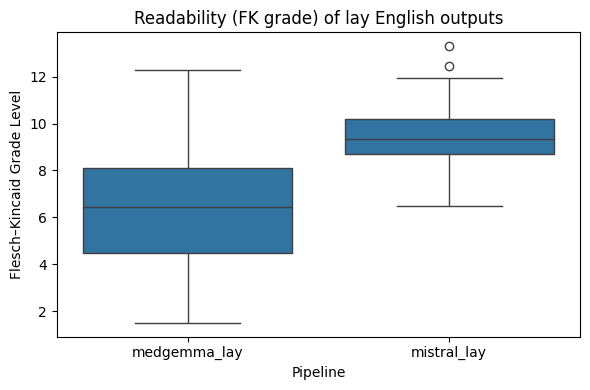

In [8]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=fk_long, x="pipeline", y="fk_grade")
plt.ylabel("Flesch–Kincaid Grade Level")
plt.xlabel("Pipeline")
plt.title("Readability (FK grade) of lay English outputs")
plt.tight_layout()
plt.savefig("fk_boxplot_medgemma_vs_mistral.png", dpi=300)


# Metrics

In [9]:
from scipy import stats
import numpy as np

# FK stats (replace "gunning_fog" with "fk_grade" if your column is named differently)
med_fk = fk_long[fk_long["pipeline"] == "medgemma_lay"]["fk_grade"].dropna()
mis_fk = fk_long[fk_long["pipeline"] == "mistral_lay"]["fk_grade"].dropna()

print("=== FLESCH–KINCAID GRADE LEVEL ===")
print("Descriptive statistics by pipeline:")
fk_desc = fk_long.groupby("pipeline")["fk_grade"].describe()
print(fk_desc)

# Statistical test
t_stat_fk, p_val_fk = stats.ttest_ind(med_fk, mis_fk, equal_var=False)
print(f"\nWelch's t-test: t = {t_stat_fk:.3f}, p = {p_val_fk:.6f}")

# Effect size
cohens_d_fk = (med_fk.mean() - mis_fk.mean()) / np.sqrt((med_fk.var() + mis_fk.var()) / 2)
print(f"Cohen's d = {cohens_d_fk:.3f}")

# CI
mean_diff_fk = med_fk.mean() - mis_fk.mean()
se_diff_fk = np.sqrt(med_fk.var()/len(med_fk) + mis_fk.var()/len(mis_fk))
ci_low_fk = mean_diff_fk - 1.96 * se_diff_fk
ci_high_fk = mean_diff_fk + 1.96 * se_diff_fk
print(f"95% CI for mean difference: [{ci_low_fk:.2f}, {ci_high_fk:.2f}]")


=== FLESCH–KINCAID GRADE LEVEL ===
Descriptive statistics by pipeline:
              count      mean       std       min       25%       50%  \
pipeline                                                                
medgemma_lay  417.0  6.390154  2.520873  1.500000  4.485714  6.423590   
mistral_lay   417.0  9.417143  1.096525  6.491429  8.698516  9.339616   

                    75%        max  
pipeline                            
medgemma_lay   8.087692  12.278721  
mistral_lay   10.175385  13.304046  

Welch's t-test: t = -22.485, p = 0.000000
Cohen's d = -1.557
95% CI for mean difference: [-3.29, -2.76]


In [17]:
import pandas as pd

summary_table = pd.DataFrame({
    "Metric": ["FK Grade Level", "Gunning Fog Index"],
    "MedGemma M (SD)": ["6.39 (2.52)", "9.37 (3.52)"],
    "Mistral M (SD)": ["9.42 (1.10)", "11.64 (1.43)"],
    "t(832)": ["-22.49***", "-12.22***"],
    "Cohen's d": ["-1.56", "-0.85"],
})

print("Table 1: Readability comparison")
print(summary_table.to_markdown(index=False))
print("\n*** p < 0.001")



Table 1: Readability comparison
| Metric            | MedGemma M (SD)   | Mistral M (SD)   | t(832)    |   Cohen's d |
|:------------------|:------------------|:-----------------|:----------|------------:|
| FK Grade Level    | 6.39 (2.52)       | 9.42 (1.10)      | -22.49*** |       -1.56 |
| Gunning Fog Index | 9.37 (3.52)       | 11.64 (1.43)     | -12.22*** |       -0.85 |

*** p < 0.001


In [18]:
for pipeline, path, col in configs:
    df = pd.read_csv(path)
    texts = df[col].fillna("").astype(str)
    df[f"{col}_FK"] = [textstat.flesch_kincaid_grade(t) if t.strip() else np.nan for t in texts]
    df[f"{col}_GunningFog"] = [textstat.gunning_fog(t) if t.strip() else np.nan for t in texts]
    df.to_csv(path.replace(".csv", "_with_readability.csv"), index=False)
